In [ ]:
# %% Libraries
import os
import scanpy as sc
#import scvi
import numpy as np
from pathlib import Path
import pandas as pd
#import novae
import matplotlib.pyplot as plt

import os
import plotnine as p9

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
CUR_OBJ_V = 'refined-manual-niches'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{CUR_OBJ_V}.h5ad'

# %% Load the object
comb = sc.read_h5ad(CUR_OBJ_PATH)



In [ ]:
PLOTS_DIR = MAIN_DIR/ 'results/comb/plots/manual-niches'

In [ ]:
comb

## get the proprotions

In [ ]:
ct_labels = "ann_lvl_3_refined"
niche_col = "niche_name"

# 1) Subset obs columns
df = comb.obs[
    [ct_labels, niche_col]
].copy().dropna()

# 2) Count cells per niche × cell type
plot_data = (
    df.groupby(
        [niche_col, ct_labels],
        observed=True
    )
    .size()
    .reset_index(name="count")
)

# 3) Calculate cell-type proportions within each niche
plot_data["proportion"] = (
    plot_data["count"] /
    plot_data.groupby(niche_col)["count"].transform("sum")
)

plot_data['percentage'] = plot_data['proportion']*100
airway_comp = (
    plot_data[
        plot_data["niche_name"] == "airway_epithelium"
    ]
    .sort_values("percentage", ascending=False)
)

airway_comp

## get the proportions per condition

In [ ]:
ct_labels = "ann_lvl_3_refined"
niche_col = "niche_name"
condition_col = 'condition'

# 1) Subset obs columns
df = comb.obs[
    [ct_labels, niche_col, condition_col]
].copy().dropna()

# 2) Count cells per niche × cell type
plot_data = (
    df.groupby(
        [niche_col, ct_labels],
        observed=True
    )
    .size()
    .reset_index(name="count")
)

# 3) Calculate cell-type proportions within each niche
plot_data["proportion"] = (
    plot_data["count"] /
    plot_data.groupby(niche_col)["count"].transform("sum")
)

plot_data['percentage'] = plot_data['proportion']*100
airway_comp = (
    plot_data[
        plot_data["niche_name"] == "airway_epithelium"
    ]
    .sort_values("percentage", ascending=False)
)

airway_comp

## Heatmap plot (paper version)

/tmp/ipykernel_4023889/1412836197.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


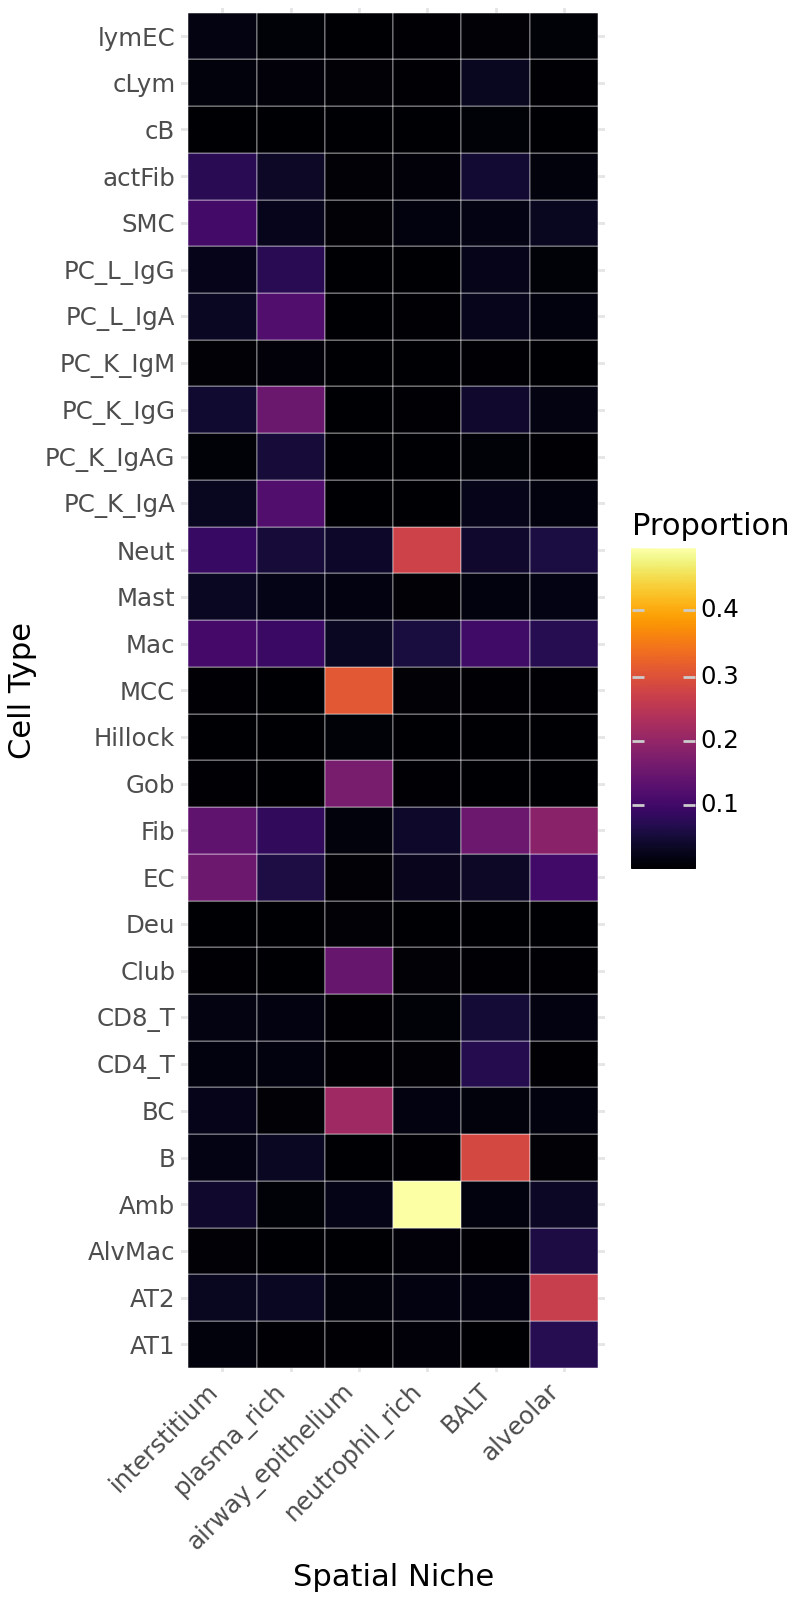

In [4]:
# %% Plot niche composition

import plotnine as p9

ct_labels = "ann_lvl_3_refined"
niche_col = "niche_name"

# 1) Subset obs columns
df = comb.obs[
    [ct_labels, niche_col]
].copy().dropna()

# 2) Count cells per niche × cell type
plot_data = (
    df.groupby(
        [niche_col, ct_labels],
        observed=True
    )
    .size()
    .reset_index(name="count")
)

# 3) Calculate cell-type proportions within each niche
plot_data["proportion"] = (
    plot_data["count"] /
    plot_data.groupby(niche_col)["count"].transform("sum")
)

# 4) Plot
p = (
    p9.ggplot(
        plot_data,
        p9.aes(
            x=niche_col,
            y=ct_labels,
            fill="proportion"
        )
    )
    + p9.geom_tile(color="white")
    + p9.scale_fill_cmap(cmap_name="inferno")
    + p9.labs(
        y="Cell Type",
        x="Spatial Niche",
        fill="Proportion"
    )
    + p9.theme_minimal()
    + p9.theme(
        axis_text_x=p9.element_text(
            rotation=45,
            ha="right"
        ),
        figure_size=(4, 8)
    )
)

p

In [7]:
plot_data['percentage'] = plot_data['proportion']*100
airway_comp = (
    plot_data[
        plot_data["niche_name"] == "airway_epithelium"
    ]
    .sort_values("percentage", ascending=False)
)

airway_comp

,niche_name,ann_lvl_3_refined,count,proportion,percentage
72,airway_epithelium,MCC,72413,0.307317,30.731656
63,airway_epithelium,BC,50243,0.213228,21.322837
70,airway_epithelium,Gob,39248,0.166566,16.656623
66,airway_epithelium,Club,34238,0.145304,14.530408
75,airway_epithelium,Neut,8447,0.035849,3.584858
73,airway_epithelium,Mac,7037,0.029865,2.986462
61,airway_epithelium,Amb,4587,0.019467,1.946696
74,airway_epithelium,Mast,3292,0.013971,1.397106
59,airway_epithelium,AT2,2465,0.010461,1.046132
69,airway_epithelium,Fib,2452,0.010406,1.040615


In [5]:
# %% Plot niche composition

import plotnine as p9

ct_labels = "ann_lvl_3_refined"
niche_col = "niche_name"

# 1) Subset obs columns
df = comb.obs[
    [ct_labels, niche_col]
].copy().dropna()

# 2) Count cells per niche × cell type
plot_data = (
    df.groupby(
        [niche_col, ct_labels],
        observed=True
    )
    .size()
    .reset_index(name="count")
)

# 3) Calculate cell-type proportions within each niche
plot_data["proportion"] = (
    plot_data["count"] /
    plot_data.groupby(niche_col)["count"].transform("sum")
)


/tmp/ipykernel_2967578/132946782.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [6]:
ct_order = [
    # Alveolar epithelium
    "AT1", "AT2",

    # Airway epithelium
    "BC", "Club", "Gob", "MCC", "Deu", "Hillock",

    # Myeloid
    "AlvMac", "Mac", "Neut", "Mast",

    # Lymphoid
    "B", "cB", "CD4_T", "CD8_T", "cLym",

    # Plasma
    "PC_K_IgA", "PC_L_IgA",
    "PC_K_IgG", "PC_L_IgG",
    "PC_K_IgM", "PC_K_IgAG",

    # Stromal / endothelial
    "Fib", "actFib", "SMC", "EC", "lymEC",

    # Other
    "Amb",
]

plot_data[ct_labels] = pd.Categorical(
    plot_data[ct_labels],
    categories=ct_order,
    ordered=True
)

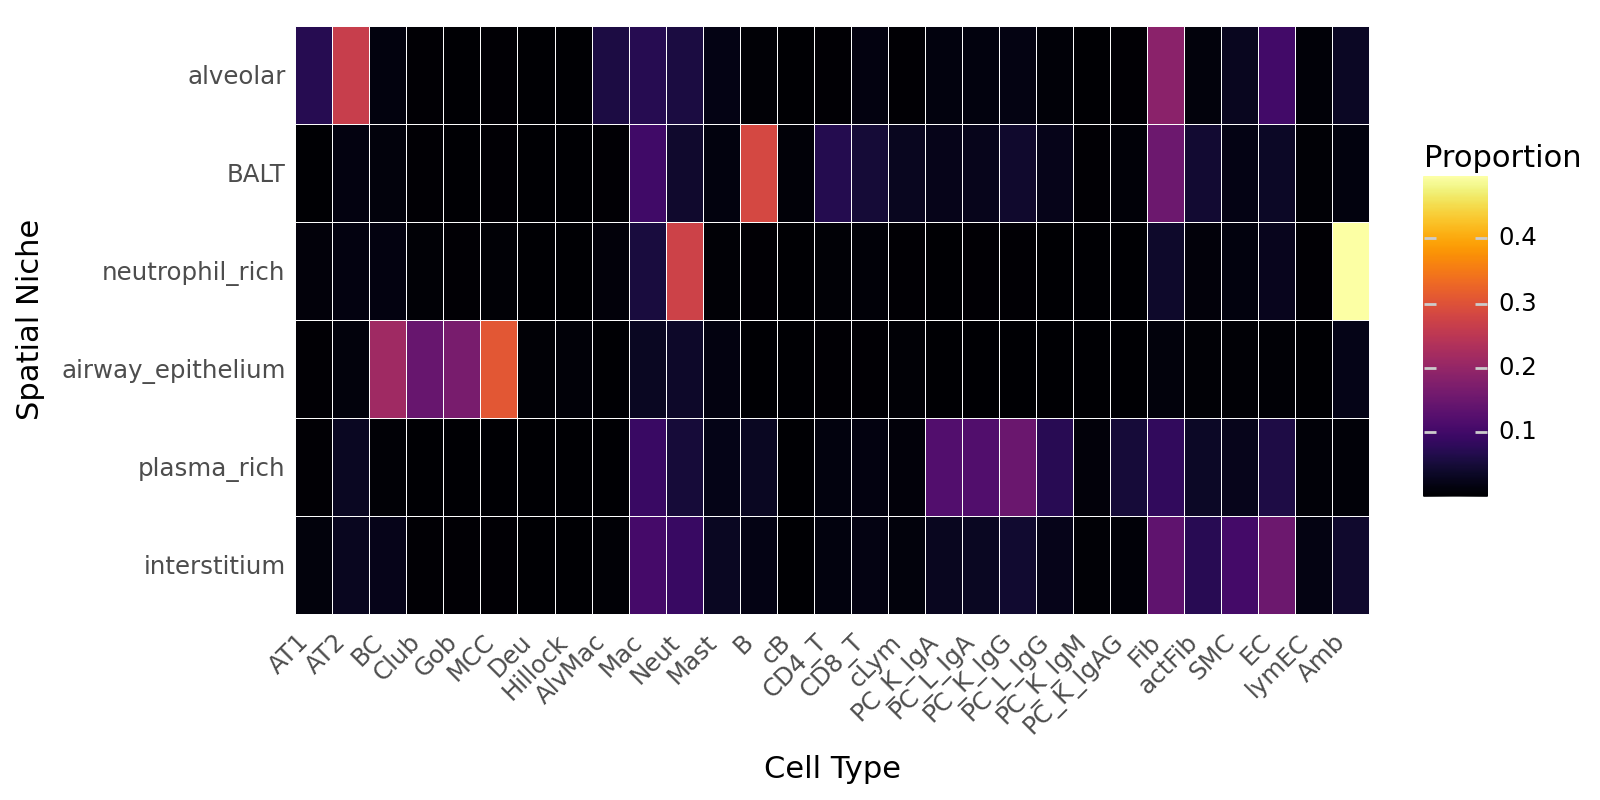

In [12]:
p = (
    p9.ggplot(
        plot_data,
        p9.aes(
            x=ct_labels,
            y=niche_col,
            fill="proportion"
        )
    )
    + p9.geom_tile(color="white", size=0.2)
    + p9.scale_fill_cmap(
        cmap_name="inferno"
    )
    + p9.labs(
        x="Cell Type",
        y="Spatial Niche",
        fill="Proportion"
    )
    + p9.theme_minimal()
    + p9.theme(
        axis_text_x=p9.element_text(
            rotation=45,
            ha="right"
        ),
        panel_grid=p9.element_blank(),
        figure_size=(8, 4)
    )
)

p

In [13]:
niche_colors = {
    "alveolar": "#8C564B",
    "BALT": "#9467BD",
    "neutrophil_rich": "#D62728",
    "airway_epithelium": "#2CA02C",
    "plasma_rich": "#FF7F0E",
    "interstitium": "#1F77B4",
}

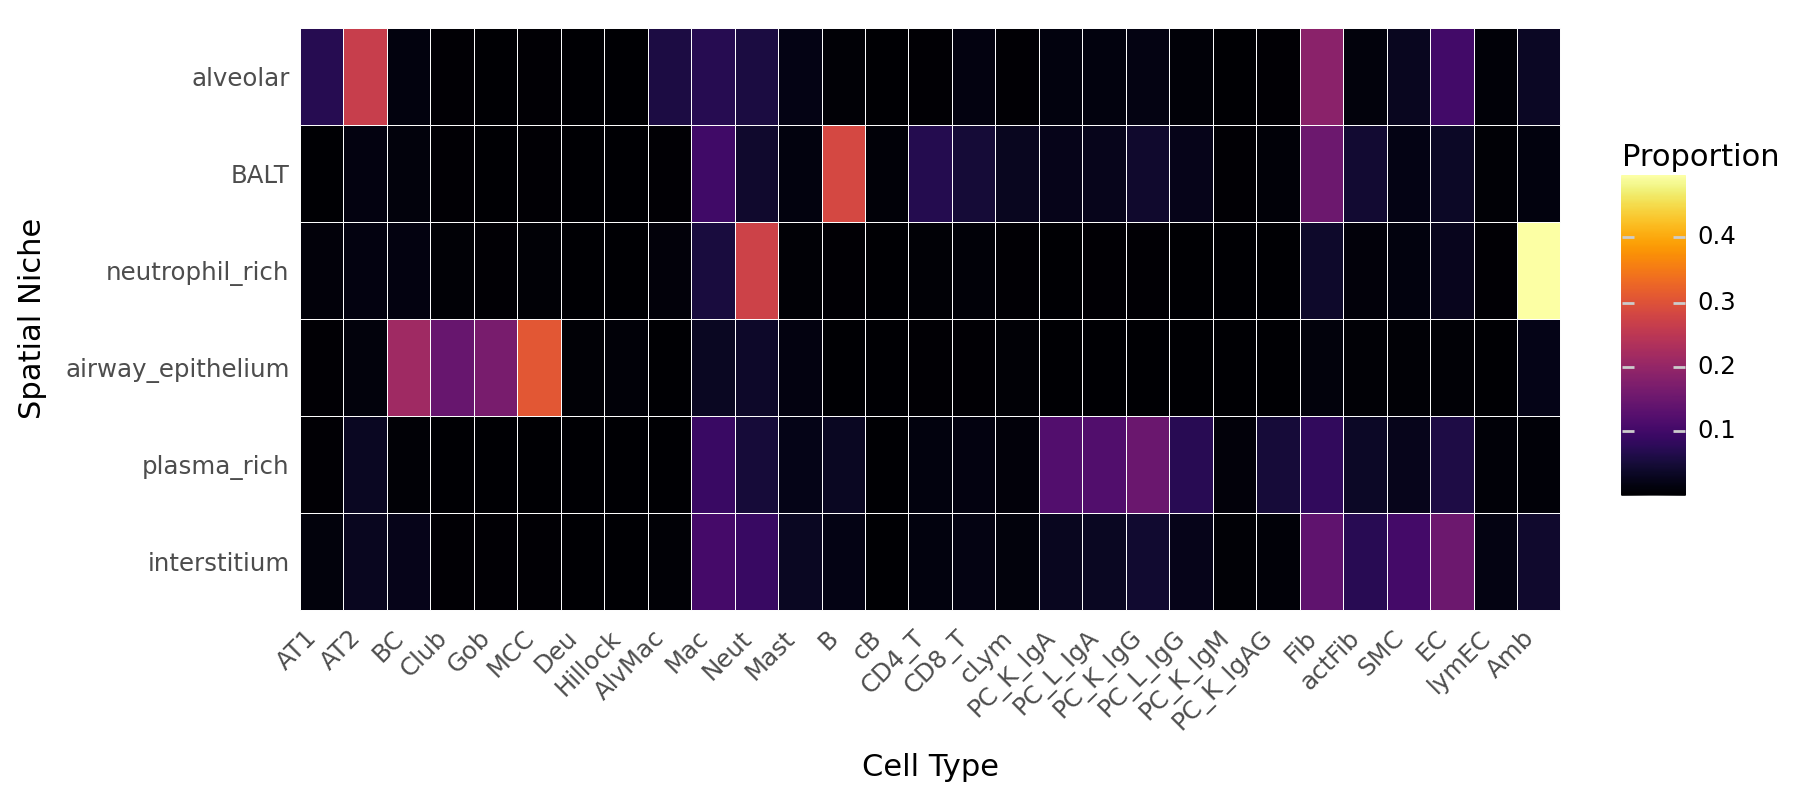

In [19]:
p = (
    p9.ggplot(
        plot_data,
        p9.aes(
            x=ct_labels,
            y=niche_col,
            fill="proportion"
        )
    )
    + p9.geom_tile(color="white", size=0.2)
    + p9.scale_fill_cmap(cmap_name="inferno")
    + p9.labs(
        x="Cell Type",
        y="Spatial Niche",
        fill="Proportion"
    )
    + p9.theme_minimal()
    + p9.theme(
        axis_text_x=p9.element_text(
            rotation=45,
            ha="right"
        ),
        panel_grid=p9.element_blank(),
        figure_size=(9, 4)
    )
)

p

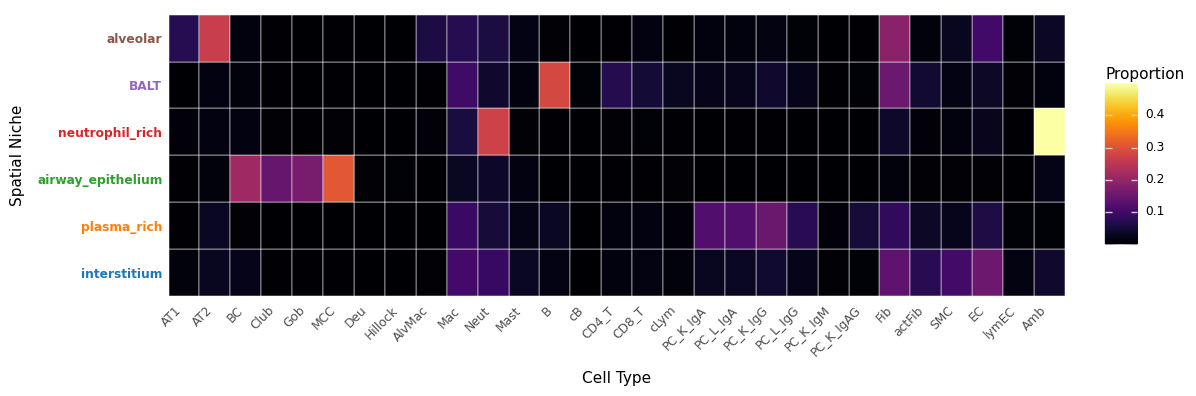

In [11]:
fig = p.draw()
ax = fig.axes[0]

for label in ax.get_yticklabels():
    niche = label.get_text()

    if niche in niche_colors:
        label.set_color(niche_colors[niche])
        label.set_fontweight("bold")

fig